## Objetivo
El objetivo de este proyecto es construir un dataset integral de satisfacción de vida para el periodo 2021-2024, integrando datos de PIB per cápita del Banco Mundial y los indicadores del Better Life Index (BLI) de la OCDE. El proceso busca aplicar técnicas de limpieza, transformación y fusión de datos (merging) para analizar la relación entre el desarrollo económico y el bienestar social, documentando cada paso para asegurar la reproducibilidad del análisis y su correcta gestión mediante control de versiones en GitHub.

### ¿Qué es el GDP y qué mide?

**Definición:** El GDP o PIB es la suma del valor monetario de todos los bienes y servicios finales producidos dentro de un país en un período determinado (normalmente un año o un trimestre).

**Qué mide:**

Tamaño de la economía: Permite comparar la riqueza generada por distintos países.

Crecimiento económico: Si el PIB aumenta respecto al año anterior, indica expansión; si disminuye, puede señalar recesión.

Actividad productiva: Refleja consumo, inversión, gasto público y exportaciones netas.

**Ejemplo práctico:** Si México produce más automóviles, alimentos y servicios en un año, el valor de esa producción se suma para calcular el PIB.

**Uso:**

Evaluar políticas económicas.

Comparar niveles de vida entre países.

Detectar ciclos económicos (expansión o recesión)

### ¿Qué es el OCDE y qué mide?

**Definición:** La OCDE es una organización internacional fundada en 1961 con sede en París. Agrupa actualmente a 38 países miembros, principalmente economías desarrolladas.

**Objetivo principal:** Promover políticas que mejoren el bienestar económico y social de las personas en todo el mundo.

**Qué mide y analiza:**

Indicadores económicos: PIB, productividad, comercio internacional, inversión.

Aspectos sociales: Educación, salud, igualdad de género, empleo.

Bienestar y desarrollo sostenible: Calidad de vida, innovación, medio ambiente.

Herramientas:

Publica estudios comparativos y estadísticas internacionales.

Establece estándares y recomendaciones de políticas públicas.

**Ejemplo práctico:** La OCDE mide el desempeño educativo a través del examen PISA, que compara la calidad de la educación en distintos países.


### Generando figuras y el dataset

#### Como primer paso tenemos que generar una función para guardar cada una de las figuras

In [ ]:
from pathlib import Path

# Where to save the figures
IMAGES_PATH = Path() / "images" / "fundamentals"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

### Nota importante: Debemos cargar y preparar los datos de satisfacción con la vida, los cuales obtendremos de los siguientes enlaces.

Para crear el archivo `lifesat.csv`, se descargan los datos del Índice para una Vida Mejor (Better Life Index, BLI) desde el sitio web de la OCDE (para obtener el nivel de satisfacción con la vida de cada país) [OECD's website](http://stats.oecd.org/index.aspx?DataSetCode=BLI), así como los datos de PIB per cápita del Banco Mundial desde [OurWorldInData.org](https://ourworldindata.org/grapher/gdp-per-capita-worldbank).

Los datos del BLI se encuentran en el archivo datasets/lifesat/oecd_bli.csv (correspondientes al año 2020), y los datos de PIB per cápita están en datasets/lifesat/gdp_per_capita.csv (con información  del año 2020).

**¿Qué hacen los bloques siguientes?**

- Bloque de Descarga (urllib y pathlib): Su función es garantizar que el entorno de trabajo tenga los archivos necesarios. Primero crea una estructura de directorios profesional (datasets/lifesat). Luego, hay que verificar si los archivos ya existen localmente para evitar descargas innecesarias. Esto es fundamental para la reproducibilidad: cualquier persona que ejecute el notebook en el futuro tendrá los datos automáticamente sin tener que buscarlos manualmente.

- Bloque !ls datasets/lifesat: Es un comando de consola (shell) que se ejecuta desde el notebook. Sirve para confirmar visualmente que la carpeta se creó correctamente y ver qué archivos contiene. Es el primer control de calidad tras la descarga.

- Bloque !ls datasets/lifesat/*.csv: Es un filtro específico. Al usar el comodín *, le pides al sistema que te muestre únicamente los archivos de datos (CSV). En proyectos más grandes con muchos archivos (imágenes, metadatos, etc.), esto ayuda a confirmar que los archivos de datos críticos están en su lugar.

In [ ]:
from pathlib import Path
import urllib.request

# Definir la carpeta destino localmente en el entorno del notebook
datapath = Path("datasets") / "lifesat"
datapath.mkdir(parents=True, exist_ok=True)

# URL base del repositorio en GitHub (acceso directo a los archivos raw)
data_root = "https://raw.githubusercontent.com/RossSS09/Lifesat-2021-2024/main/datasets/lifesat/"

# Lista de archivos a descargar desde el repositorio
for filename in ("OECD,DF_BLI,+all.csv", "gdp-per-capita-worldbank.csv"):
    file_path = datapath / filename
    if not file_path.is_file():
        print(f"Descargando {filename} desde el repositorio...")
        url = data_root + filename
        # Intentar la descarga
        try:
            urllib.request.urlretrieve(url, file_path)
            print(f"{filename} guardado exitosamente.")
        except Exception as e:
            print(f"Error al descargar {filename}: {e}")
    else:
        print(f"{filename} ya existe en la carpeta local.")

Descargando OECD,DF_BLI,+all.csv desde el repositorio...
OECD,DF_BLI,+all.csv guardado exitosamente.
Descargando gdp-per-capita-worldbank.csv desde el repositorio...
gdp-per-capita-worldbank.csv guardado exitosamente.


In [ ]:
# Listar el contenido de la carpeta para verificar la creación
!ls datasets/lifesat

# Listar específicamente solo los archivos con extensión .csv
!ls datasets/lifesat/*.csv

gdp-per-capita-worldbank.csv  OECD,DF_BLI,+all.csv
datasets/lifesat/gdp-per-capita-worldbank.csv
datasets/lifesat/OECD,DF_BLI,+all.csv


## Preprocesamiento de ambos datasets, para posteriormer aplicar "Merge" (la unión de los dataset ya filtrados) y finalmente guardarlos.

In [ ]:
import pandas as pd

# Carga de archivos
gdp_per_capita = pd.read_csv(datapath / "gdp-per-capita-worldbank.csv")
oecd_bli = pd.read_csv(datapath / "OECD,DF_BLI,+all.csv")

### Preprocesar los datos del OECD BLI para conservar únicamente la columna `Life satisfaction` y eliminar los espacios que puedan causar errores

In [ ]:
import pandas as pd

# Carga con limpieza de espacios iniciales
oecd_bli = pd.read_csv(datapath / "OECD,DF_BLI,+all.csv", skipinitialspace=True)
gdp_per_capita = pd.read_csv(datapath / "gdp-per-capita-worldbank.csv", skipinitialspace=True)

# LIMPIEZA DE COLUMNAS: Esto elimina espacios invisibles que puedan causar un KeyError
oecd_bli.columns = oecd_bli.columns.str.strip()
gdp_per_capita.columns = gdp_per_capita.columns.str.strip()

# Filtrado y Pivoteo
oecd_bli = oecd_bli[oecd_bli["INEQUALITY"] == "TOT"]
oecd_bli = oecd_bli.pivot(index="LOCATION", columns="INDICATOR", values="OBS_VALUE")

# Mantener solo la satisfacción y renombrar
oecd_bli = oecd_bli[["SW_LIFS"]].rename(columns={"SW_LIFS": "Life satisfaction"})

print("Datos de la OECD preparados con éxito.")
oecd_bli.head()

Datos de la OECD preparados con éxito.


INDICATOR,Life satisfaction
LOCATION,
AUS,7.1
AUT,7.2
BEL,6.8
BRA,6.1
CAN,7.0


### Preprocesar los datos del PIB año por año (2021-2024)

In [ ]:
# --- PROCESAMIENTO 2021 ---
# Filtrar PIB 2021
gdp_2021 = gdp_per_capita[gdp_per_capita["Year"] == 2021].copy()

# Renombrar columna de PIB para facilitar el manejo
gdp_col = "GDP per capita, PPP (constant 2021 international $)"
gdp_2021 = gdp_2021.rename(columns={gdp_col: "GDP per capita"})

# Unir con datos de satisfacción (Merge)
# Usamos 'LOCATION' de la OECD y 'Code' del Banco Mundial
lifesat_2021 = pd.merge(left=oecd_bli, right=gdp_2021,
                        left_index=True, right_on="Code")

# Limpiar y organizar el dataset final
lifesat_2021 = lifesat_2021[["Entity", "GDP per capita", "Life satisfaction"]]
lifesat_2021.set_index("Entity", inplace=True)
lifesat_2021.sort_values(by="GDP per capita", inplace=True)

print("Resultados 2021 (Primeras 5 filas):")
display(lifesat_2021.head())

Resultados 2021 (Primeras 5 filas):


,GDP per capita,Life satisfaction
Entity,,
South Africa,13711.294,4.9
Colombia,17383.090,5.7
Brazil,18075.705,6.1
Mexico,20782.588,6.0
Costa Rica,23852.926,6.3


In [ ]:
# --- PROCESAMIENTO 2022 ---
# Filtrar PIB 2022
gdp_2022 = gdp_per_capita[gdp_per_capita["Year"] == 2022].copy()
gdp_2022 = gdp_2022.rename(columns={gdp_col: "GDP per capita"})

# Unir (Merge)
lifesat_2022 = pd.merge(left=oecd_bli, right=gdp_2022,
                        left_index=True, right_on="Code")

# Limpiar y organizar
lifesat_2022 = lifesat_2022[["Entity", "GDP per capita", "Life satisfaction"]]
lifesat_2022.set_index("Entity", inplace=True)
lifesat_2022.sort_values(by="GDP per capita", inplace=True)

print("Resultados 2022 (Primeras 5 filas):")
display(lifesat_2022.head())

Resultados 2022 (Primeras 5 filas):


,GDP per capita,Life satisfaction
Entity,,
South Africa,13777.192,4.9
Colombia,18458.720,5.7
Brazil,18554.047,6.1
Mexico,21392.111,6.0
Costa Rica,24831.719,6.3


In [ ]:
# --- PROCESAMIENTO 2023 ---
# Filtrar PIB 2023
gdp_2023 = gdp_per_capita[gdp_per_capita["Year"] == 2023].copy()

# Renombrar columna de PIB (usando la variable gdp_col definida antes)
gdp_2023 = gdp_2023.rename(columns={gdp_col: "GDP per capita"})

# Unir con datos de satisfacción (Merge)
lifesat_2023 = pd.merge(left=oecd_bli, right=gdp_2023,
                        left_index=True, right_on="Code")

# Limpiar y organizar el dataset final
lifesat_2023 = lifesat_2023[["Entity", "GDP per capita", "Life satisfaction"]]
lifesat_2023.set_index("Entity", inplace=True)
lifesat_2023.sort_values(by="GDP per capita", inplace=True)

print("Resultados 2023 (Primeras 5 filas):")
display(lifesat_2023.head())

Resultados 2023 (Primeras 5 filas):


,GDP per capita,Life satisfaction
Entity,,
South Africa,13690.390,4.9
Colombia,18382.998,5.7
Brazil,19079.812,6.1
Mexico,21905.178,6.0
Costa Rica,25979.629,6.3


In [ ]:
# --- PROCESAMIENTO 2024 ---
# Filtrar PIB 2024
gdp_2024 = gdp_per_capita[gdp_per_capita["Year"] == 2024].copy()

# Renombrar columna de PIB
gdp_2024 = gdp_2024.rename(columns={gdp_col: "GDP per capita"})

# Unir con datos de satisfacción (Merge)
lifesat_2024 = pd.merge(left=oecd_bli, right=gdp_2024,
                        left_index=True, right_on="Code")

# Limpiar y organizar el dataset final
lifesat_2024 = lifesat_2024[["Entity", "GDP per capita", "Life satisfaction"]]
lifesat_2024.set_index("Entity", inplace=True)
lifesat_2024.sort_values(by="GDP per capita", inplace=True)

print("Resultados 2024 (Primeras 5 filas):")
display(lifesat_2024.head())

Resultados 2024 (Primeras 5 filas):


,GDP per capita,Life satisfaction
Entity,,
South Africa,13598.789,4.9
Colombia,18503.670,5.7
Brazil,19647.910,6.1
Mexico,22033.275,6.0
Costa Rica,26973.436,6.3


In [ ]:
# Creamos una carpeta para los resultados si no existe
results_path = datapath / "resultados"
results_path.mkdir(parents=True, exist_ok=True)

# Guardamos cada año en un archivo CSV independiente
lifesat_2021.to_csv(results_path / "lifesat_2021.csv")
lifesat_2022.to_csv(results_path / "lifesat_2022.csv")
lifesat_2023.to_csv(results_path / "lifesat_2023.csv")
lifesat_2024.to_csv(results_path / "lifesat_2024.csv")

print(f"Archivos guardados exitosamente en: {results_path}")

# Verificamos que aparezcan en la carpeta
!ls datasets/lifesat/resultados

Archivos guardados exitosamente en: datasets/lifesat/resultados
lifesat_2021.csv  lifesat_2022.csv  lifesat_2023.csv  lifesat_2024.csv


###¿Qué estamos haciendo en estos bloques?

- El objetivo de estas secciones es la Exploración Visual de Datos (EDA). Lo que se espera ver es la dispersión de los países en un plano bidimensional donde el eje horizontal ($X$) representa la riqueza económica (PIB) y el eje vertical ($y$) representa el bienestar subjetivo.

- Se busca: Observar si los puntos siguen una tendencia ascendente (correlación positiva).Se extraen valores: Aunque aún no entrenamos, dejamos listos los arreglos de NumPy (X y y) por si se requieren más adelante.

In [ ]:
import matplotlib.pyplot as plt

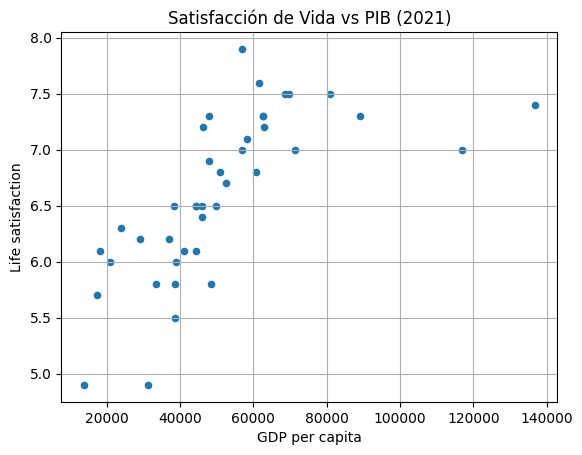

In [ ]:
# --- VISUALIZACIÓN 2021 ---
# Extraemos los valores para X (PIB) y y (Satisfacción)
X_2021 = lifesat_2021[["GDP per capita"]].values
y_2021 = lifesat_2021[["Life satisfaction"]].values

# Generamos el gráfico de dispersión
lifesat_2021.plot(kind='scatter', grid=True,
                  x="GDP per capita", y="Life satisfaction")
plt.title("Satisfacción de Vida vs PIB (2021)")
plt.show()

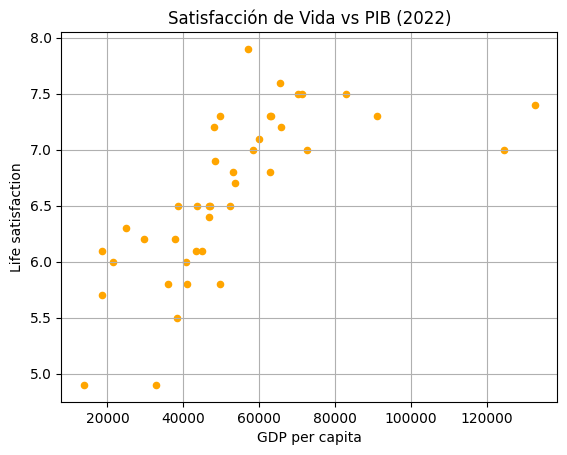

In [ ]:
# --- VISUALIZACIÓN 2022 ---
# Extraemos los valores
X_2022 = lifesat_2022[["GDP per capita"]].values
y_2022 = lifesat_2022[["Life satisfaction"]].values

# Generamos el gráfico
lifesat_2022.plot(kind='scatter', grid=True,
                  x="GDP per capita", y="Life satisfaction", color="orange")
plt.title("Satisfacción de Vida vs PIB (2022)")
plt.show()

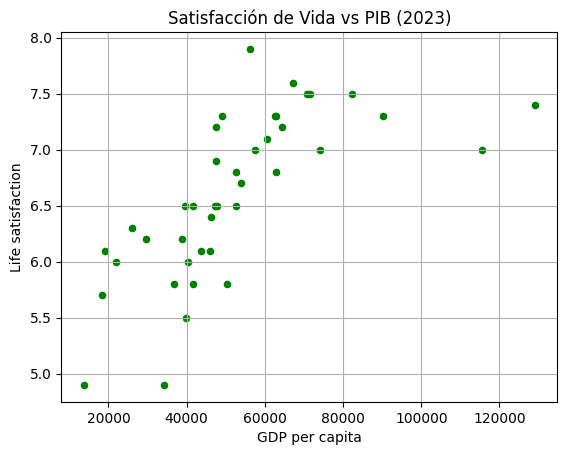

In [ ]:
# --- VISUALIZACIÓN 2023 ---
# Extraemos los valores
X_2023 = lifesat_2023[["GDP per capita"]].values
y_2023 = lifesat_2023[["Life satisfaction"]].values

# Generamos el gráfico
lifesat_2023.plot(kind='scatter', grid=True,
                  x="GDP per capita", y="Life satisfaction", color="green")
plt.title("Satisfacción de Vida vs PIB (2023)")
plt.show()

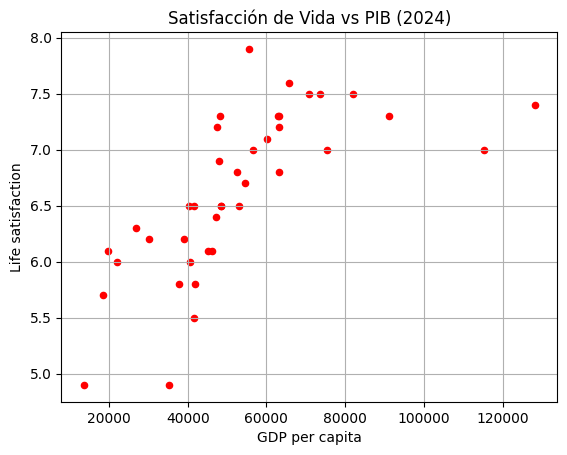

In [ ]:
# --- VISUALIZACIÓN 2024 ---
# Extraemos los valores
X_2024 = lifesat_2024[["GDP per capita"]].values
y_2024 = lifesat_2024[["Life satisfaction"]].values

# Generamos el gráfico
lifesat_2024.plot(kind='scatter', grid=True,
                  x="GDP per capita", y="Life satisfaction", color="red")
plt.title("Satisfacción de Vida vs PIB (2024)")
plt.show()

### Ilustrar el riesgo de **sobreajuste (overfitting)**

Bloque: Filtrado y Guardado del Dataset 2021
Explicación: Se establece el rango de PIB entre 23,500 y 62,500 USD para 2021. El resultado se guarda en un archivo físico para asegurar que el entrenamiento posterior use únicamente datos normalizados, así posteriormente con los siguientes años

In [ ]:
# Definición de límites
min_gdp = 23_500
max_gdp = 62_500

# Filtrado del dataset 2021
lifesat_2021_final = lifesat_2021[(lifesat_2021["GDP per capita"] >= min_gdp) &
                                   (lifesat_2021["GDP per capita"] <= max_gdp)]

# Guardado en el archivo solicitado
lifesat_2021_final.to_csv(datapath / "lifesat_2021.csv")

print("Archivo 'lifesat_2021.csv' creado exitosamente.")

Archivo 'lifesat_2021.csv' creado exitosamente.


In [ ]:
# Filtrado del dataset 2022
lifesat_2022_final = lifesat_2022[(lifesat_2022["GDP per capita"] >= min_gdp) &
                                   (lifesat_2022["GDP per capita"] <= max_gdp)]

# Guardar
lifesat_2022_final.to_csv(datapath / "lifesat_2022.csv")

print("Archivo 'lifesat_2022.csv' creado exitosamente.")

Archivo 'lifesat_2022.csv' creado exitosamente.


In [ ]:
# Filtrado del dataset 2023
lifesat_2023_final = lifesat_2023[(lifesat_2023["GDP per capita"] >= min_gdp) &
                                   (lifesat_2023["GDP per capita"] <= max_gdp)]

# Guardar
lifesat_2023_final.to_csv(datapath / "lifesat_2023.csv")

print("Archivo 'lifesat_2023.csv' creado exitosamente.")

Archivo 'lifesat_2023.csv' creado exitosamente.


In [ ]:
# Filtrado del dataset 2024
lifesat_2024_final = lifesat_2024[(lifesat_2024["GDP per capita"] >= min_gdp) &
                                   (lifesat_2024["GDP per capita"] <= max_gdp)]

# Guardar
lifesat_2024_final.to_csv(datapath / "lifesat_2024.csv")

print("Archivo 'lifesat_2024.csv' creado exitosamente.")

Archivo 'lifesat_2024.csv' creado exitosamente.


### Sección: Visualización del Rango Representativo 2021

Explicación: En este bloque trazamos únicamente los países con un PIB per cápita medio para el año 2021. El objetivo es observar la correlación más pura entre ingresos y felicidad, eliminando los valores atípicos que podrían causar un sobreajuste del modelo lineal. Así con los siguientes años también.

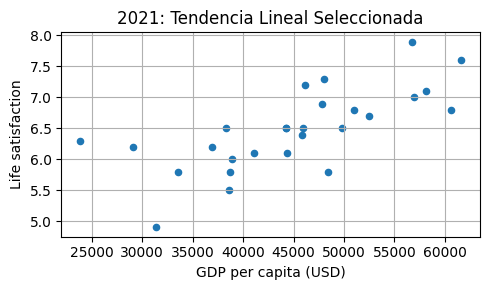

In [ ]:
import matplotlib.pyplot as plt

# Configuramos la figura
fig, ax = plt.subplots(figsize=(5, 3))

# Trazamos los datos filtrados de 2021
lifesat_2021_final.plot(kind='scatter', grid=True,
                         x="GDP per capita", y="Life satisfaction", ax=ax)

ax.set_title("2021: Tendencia Lineal Seleccionada")
ax.set_xlabel("GDP per capita (USD)")
ax.set_ylabel("Life satisfaction")

save_fig("plot_representativo_2021")
plt.show()

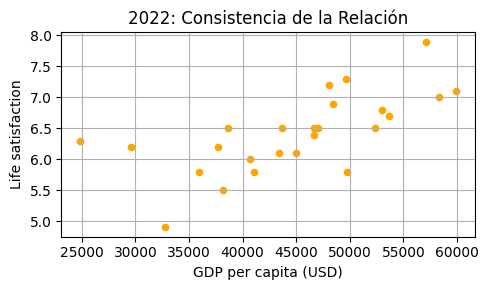

In [ ]:
# Configuramos la figura
fig, ax = plt.subplots(figsize=(5, 3))

# Trazamos los datos filtrados de 2022
lifesat_2022_final.plot(kind='scatter', grid=True,
                         x="GDP per capita", y="Life satisfaction", ax=ax, color="orange")

ax.set_title("2022: Consistencia de la Relación")
ax.set_xlabel("GDP per capita (USD)")
ax.set_ylabel("Life satisfaction")

save_fig("plot_representativo_2022")
plt.show()

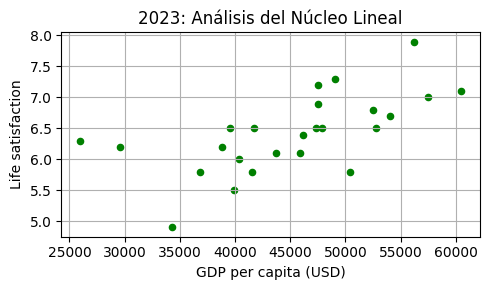

In [ ]:
# Configuramos la figura
fig, ax = plt.subplots(figsize=(5, 3))

# Trazamos los datos filtrados de 2023
lifesat_2023_final.plot(kind='scatter', grid=True,
                         x="GDP per capita", y="Life satisfaction", ax=ax, color="green")

ax.set_title("2023: Análisis del Núcleo Lineal")
ax.set_xlabel("GDP per capita (USD)")
ax.set_ylabel("Life satisfaction")

save_fig("plot_representativo_2023")
plt.show()

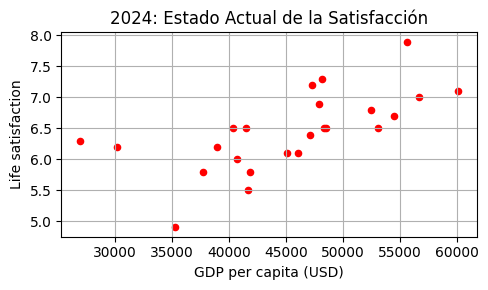

In [ ]:
# Configuramos la figura
fig, ax = plt.subplots(figsize=(5, 3))

# Trazamos los datos filtrados de 2024
lifesat_2024_final.plot(kind='scatter', grid=True,
                         x="GDP per capita", y="Life satisfaction", ax=ax, color="red")

ax.set_title("2024: Estado Actual de la Satisfacción")
ax.set_xlabel("GDP per capita (USD)")
ax.set_ylabel("Life satisfaction")

save_fig("plot_representativo_2024")
plt.show()

### Sección:

Identificación de Países No Representativos (2021-2024)
Explicación General: En esta sección identificamos los países que quedaron fuera de nuestro modelo lineal. Estos se dividen en dos grupos: países con economías en desarrollo (PIB bajo) y países con economías extremadamente ricas (PIB muy alto). Veremos que estos países suelen tener niveles de satisfacción que se alejan de la tendencia central, lo que justifica su exclusión para evitar el sobreajuste.

In [ ]:
# 1. Definimos la lista de países que queremos "etiquetar" en las gráficas
# (Son los que rompen la regla lineal)
paises_outliers = ["South Africa", "Brazil", "Mexico", "United States", "Switzerland", "Luxembourg"]

# 2. Función rápida para encontrar quiénes quedaron fuera en un año específico
def obtener_excluidos(full_df, filtered_df):
    return full_df[~full_df.index.isin(filtered_df.index)]

# Ejecutamos para cada año (comparando el full con el final)
excluidos_2021 = obtener_excluidos(lifesat_2021, lifesat_2021_final)
excluidos_2022 = obtener_excluidos(lifesat_2022, lifesat_2022_final)
excluidos_2023 = obtener_excluidos(lifesat_2023, lifesat_2023_final)
excluidos_2024 = obtener_excluidos(lifesat_2024, lifesat_2024_final)

print("Ejemplo de países excluidos en 2021:")
display(excluidos_2021[["GDP per capita", "Life satisfaction"]].head())

Ejemplo de países excluidos en 2021:


,GDP per capita,Life satisfaction
Entity,,
South Africa,13711.294,4.9
Colombia,17383.090,5.7
Brazil,18075.705,6.1
Mexico,20782.588,6.0
Germany,62530.766,7.3


In [ ]:
# Identificar excluidos 2022
excluidos_2022 = obtener_excluidos(lifesat_2022, lifesat_2022_final)

print("Países excluidos en 2022 (Muestra de los extremos):")
display(excluidos_2022[["GDP per capita", "Life satisfaction"]].sort_values("GDP per capita"))

Países excluidos en 2022 (Muestra de los extremos):


,GDP per capita,Life satisfaction
Entity,,
South Africa,13777.192,4.9
Colombia,18458.720,5.7
Brazil,18554.047,6.1
Mexico,21392.111,6.0
Belgium,62744.203,6.8
Germany,62931.970,7.3
Sweden,63215.438,7.3
Iceland,65475.410,7.6
Austria,65661.450,7.2


In [ ]:
# Identificar excluidos 2023
excluidos_2023 = obtener_excluidos(lifesat_2023, lifesat_2023_final)

print("Países excluidos en 2023 (Muestra de los extremos):")
display(excluidos_2023[["GDP per capita", "Life satisfaction"]].sort_values("GDP per capita"))

Países excluidos en 2023 (Muestra de los extremos):


,GDP per capita,Life satisfaction
Entity,,
South Africa,13690.390,4.9
Colombia,18382.998,5.7
Brazil,19079.812,6.1
Mexico,21905.178,6.0
Germany,62686.540,7.3
Sweden,62845.484,7.3
Belgium,62920.645,6.8
Austria,64394.090,7.2
Iceland,67177.200,7.6


In [ ]:
# Identificar excluidos 2024
excluidos_2024 = obtener_excluidos(lifesat_2024, lifesat_2024_final)

print("Países excluidos en 2024 (Muestra de los extremos):")
display(excluidos_2024[["GDP per capita", "Life satisfaction"]].sort_values("GDP per capita"))

Países excluidos en 2024 (Muestra de los extremos):


,GDP per capita,Life satisfaction
Entity,,
South Africa,13598.789,4.9
Colombia,18503.670,5.7
Brazil,19647.910,6.1
Mexico,22033.275,6.0
Germany,62829.797,7.3
Belgium,63083.184,6.8
Sweden,63258.906,7.3
Austria,63314.460,7.2
Iceland,65645.090,7.6


### En esta sección, generamos la referencia técnica de los gráficos de dispersión para los países excluidos (outliers) de los periodos 2021 a 2024. Al ejecutar estos comandos de forma cruda, buscamos validar que el motor de visualización ha mapeado correctamente el sistema de coordenadas para los países que quedan fuera del rango representativo. La salida numérica resultante (objeto Text) confirma la posición y asignación de etiquetas en los ejes, asegurando que la configuración sea consistente para el análisis comparativo entre el núcleo lineal y los valores extremos de cada año.

Text(0, 0.5, 'Life satisfaction')

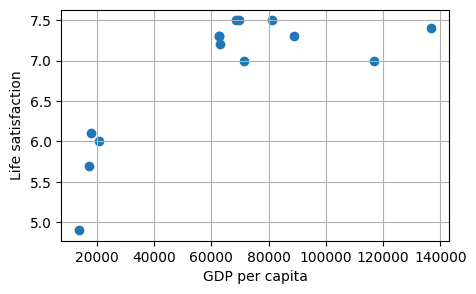

In [ ]:
# 2021

# Variables ya definidas en pasos anteriores
gdppc_col = "GDP per capita"
lifesat_col = "Life satisfaction"

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(
    excluidos_2021[gdppc_col],
    excluidos_2021[lifesat_col]
)

ax.grid(True)
ax.set_xlabel(gdppc_col)
ax.set_ylabel(lifesat_col)

Text(0, 0.5, 'Life satisfaction')

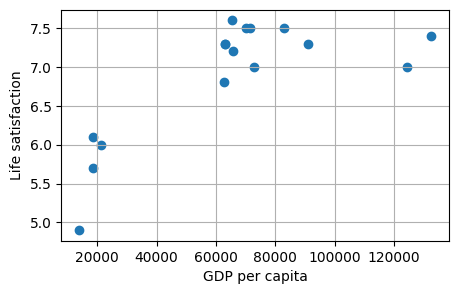

In [ ]:
# 2022
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(
    excluidos_2022[gdppc_col],
    excluidos_2022[lifesat_col]
)

ax.grid(True)
ax.set_xlabel(gdppc_col)
ax.set_ylabel(lifesat_col)

Text(0, 0.5, 'Life satisfaction')

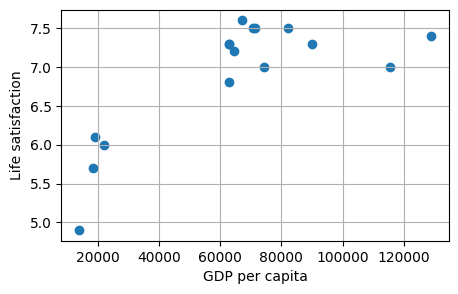

In [ ]:
# 2023

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(
    excluidos_2023[gdppc_col],
    excluidos_2023[lifesat_col]
)

ax.grid(True)
ax.set_xlabel(gdppc_col)
ax.set_ylabel(lifesat_col)

Text(0, 0.5, 'Life satisfaction')

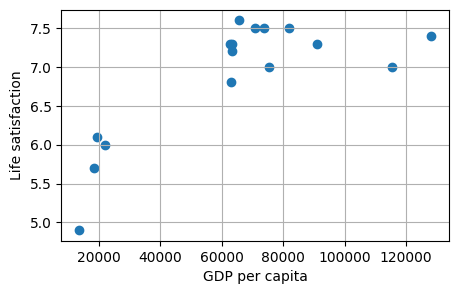

In [ ]:
# 2024

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(
    excluidos_2024[gdppc_col],
    excluidos_2024[lifesat_col]
)

ax.grid(True)
ax.set_xlabel(gdppc_col)
ax.set_ylabel(lifesat_col)

### En esta etapa, visualizamos el panorama completo de los datos para justificar la exclusión de ciertos países. Los puntos azules representan a las naciones que siguen la tendencia lineal (rango representativo), mientras que los puntos rojos representan a los países que se identificaron como excluidos por tener un PIB demasiado bajo o demasiado alto.

### El objetivo de esta comparación es prevenir el sobreajuste (overfitting). Si incluyéramos los puntos rojos en el entrenamiento, "forzaríamos" al modelo lineal a intentar alcanzarlos, lo que resultaría en una línea inclinada incorrectamente que no representaría bien a ninguno de los dos grupos. Al aislarlos visualmente, validamos que nuestro modelo debe enfocarse únicamente en el núcleo representativo para ser preciso.

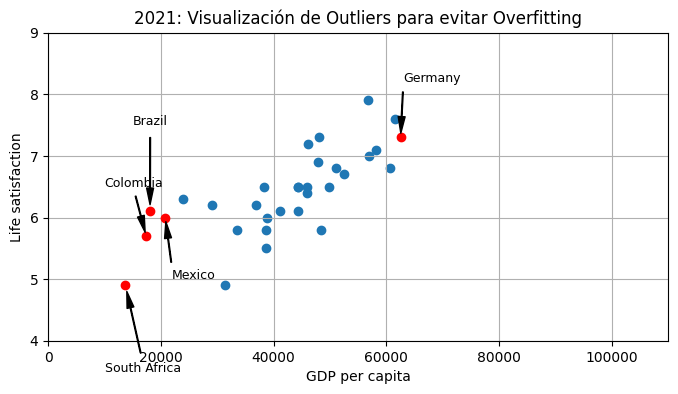

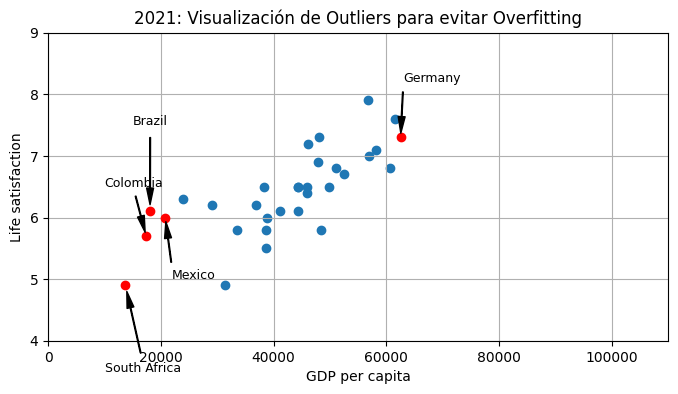

In [62]:
# 2021

excluidos_2021 = {
    "South Africa": (13711.294, 4.9), "Colombia": (17383.090, 5.7),
    "Brazil": (18075.705, 6.1), "Mexico": (20782.588, 6.0), "Germany": (62530.766, 7.3)
}

# Coordenadas para etiquetas
pos_2021 = {"South Africa": (10000, 3.5), "Mexico": (22000, 5.0), "Germany": (63000, 8.2),
            "Brazil": (15000, 7.5), "Colombia": (10000, 6.5)}

fig, ax = plt.subplots(figsize=(8, 4))

# Los representativos en azul
ax.scatter(lifesat_2021_final[gdppc_col], lifesat_2021_final[lifesat_col], label="Representativos")

# Agregamos los excluidos en rojo con etiquetas
for country, (x, y) in excluidos_2021.items():
    ax.plot(x, y, "ro")
    ax.annotate(country, xy=(x, y), xytext=pos_2021[country], fontsize=9,
                arrowprops=dict(facecolor="black", width=0.5, shrink=0.08, headwidth=5))

ax.set_xlim(0, 110_000)
ax.set_ylim(4, 9)
ax.set_xlabel(gdppc_col)
ax.set_ylabel(lifesat_col)
ax.grid(True)
ax.set_title("2021: Visualización de Outliers para evitar Overfitting")
fig

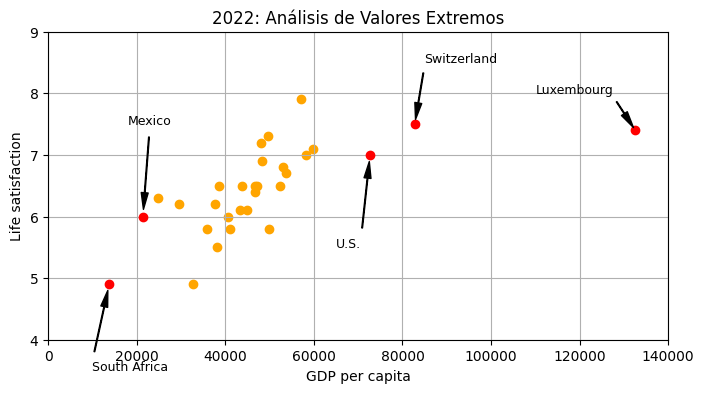

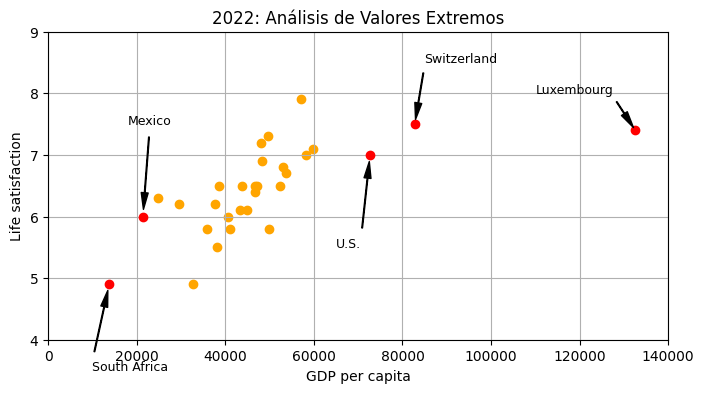

In [63]:
# Usamos una muestra de los datos para evitar saturar el gráfico
excluidos_2022 = {
    "South Africa": (13777.192, 4.9), "Mexico": (21392.111, 6.0),
    "United States": (72679.260, 7.0), "Switzerland": (82777.300, 7.5), "Luxembourg": (132574.0, 7.4)
}

pos_2022 = {"South Africa": (10000, 3.5), "Mexico": (18000, 7.5),
            "United States": (65000, 5.5), "Switzerland": (85000, 8.5), "Luxembourg": (110000, 8.0)}

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(lifesat_2022_final[gdppc_col], lifesat_2022_final[lifesat_col], color="orange")

for country, (x, y) in excluidos_2022.items():
    ax.plot(x, y, "ro")
    label = "U.S." if country == "United States" else country
    ax.annotate(label, xy=(x, y), xytext=pos_2022[country], fontsize=9,
                arrowprops=dict(facecolor="black", width=0.5, shrink=0.08, headwidth=5))

ax.set_xlim(0, 140_000)
ax.set_ylim(4, 9)
ax.set_xlabel(gdppc_col)
ax.set_ylabel(lifesat_col)
ax.grid(True)
ax.set_title("2022: Análisis de Valores Extremos")
fig

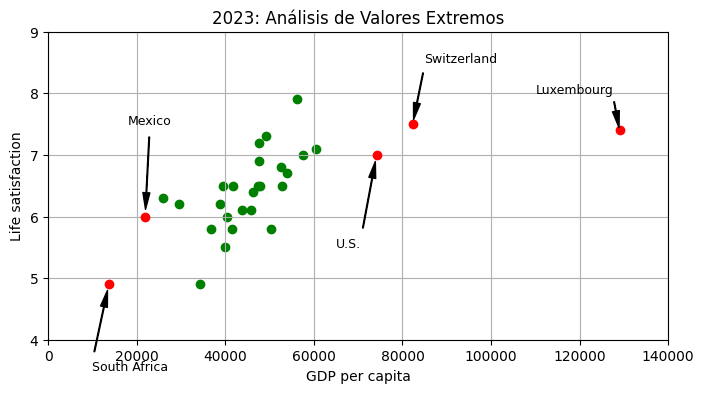

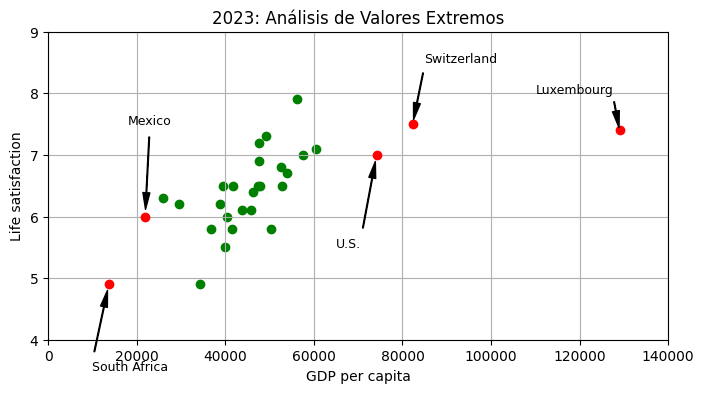

In [64]:
excluidos_2023 = {
    "South Africa": (13690.390, 4.9), "Mexico": (21905.178, 6.0),
    "United States": (74158.720, 7.0), "Switzerland": (82302.050, 7.5), "Luxembourg": (129021.65, 7.4)
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(lifesat_2023_final[gdppc_col], lifesat_2023_final[lifesat_col], color="green")

for country, (x, y) in excluidos_2023.items():
    ax.plot(x, y, "ro")
    label = "U.S." if country == "United States" else country
    ax.annotate(label, xy=(x, y), xytext=pos_2022[country], fontsize=9, # Reutilizamos posiciones similares
                arrowprops=dict(facecolor="black", width=0.5, shrink=0.08, headwidth=5))

ax.set_xlim(0, 140_000)
ax.set_ylim(4, 9)
ax.set_xlabel(gdppc_col)
ax.set_ylabel(lifesat_col)
ax.grid(True)
ax.set_title("2023: Análisis de Valores Extremos")
fig

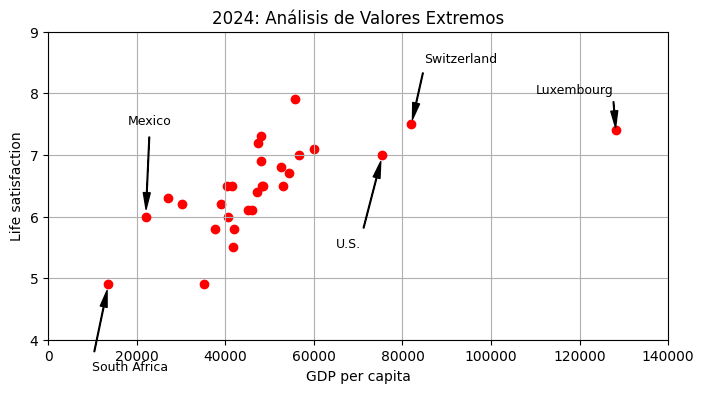

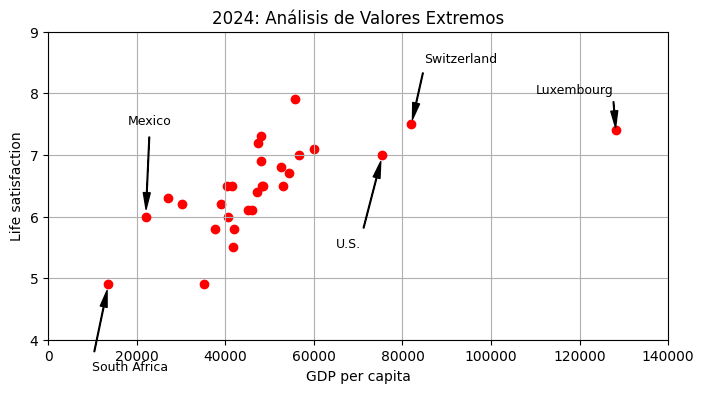

In [65]:
excluidos_2024 = {
    "South Africa": (13598.789, 4.9), "Mexico": (22033.275, 6.0),
    "United States": (75491.610, 7.0), "Switzerland": (82026.410, 7.5), "Luxembourg": (128181.70, 7.4)
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(lifesat_2024_final[gdppc_col], lifesat_2024_final[lifesat_col], color="red")

for country, (x, y) in excluidos_2024.items():
    ax.plot(x, y, "ro")
    label = "U.S." if country == "United States" else country
    ax.annotate(label, xy=(x, y), xytext=pos_2022[country], fontsize=9,
                arrowprops=dict(facecolor="black", width=0.5, shrink=0.08, headwidth=5))

ax.set_xlim(0, 140_000)
ax.set_ylim(4, 9)
ax.set_xlabel(gdppc_col)
ax.set_ylabel(lifesat_col)
ax.grid(True)
ax.set_title("2024: Análisis de Valores Extremos")
fig

### Visualización de Parámetros $\theta$

###Explicación General: En esta sección no estamos entrenando el modelo todavía; estamos explorando el espacio de parámetros. Un modelo lineal se define por su intercepto ($\theta_0$) y su pendiente ($\theta_1$). Aquí visualizamos tres "candidatos" a modelo: uno constante (rojo), uno con tendencia negativa (verde) y uno con tendencia positiva (azul). El objetivo de este ejercicio es entender visualmente cómo el cambio de estos valores altera la recta y cuál de ellas parece acercarse más a la nube de puntos de cada año.

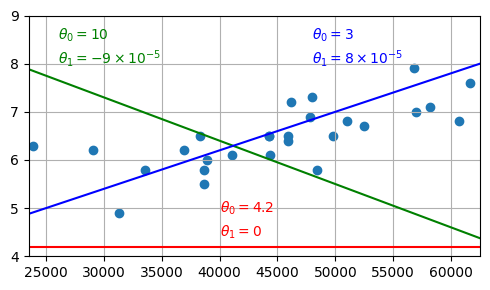

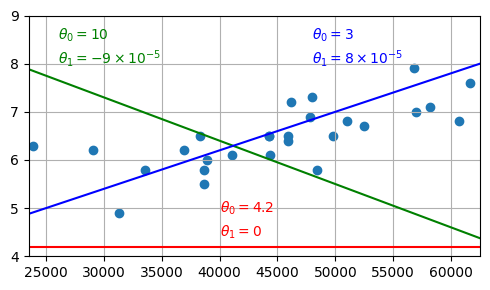

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de variables
min_gdp, max_gdp = 23_500, 62_500
min_life_sat, max_life_sat = 4, 9
gdppc_col = "GDP per capita"
lifesat_col = "Life satisfaction"
country_stats = lifesat_2021_final

fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(
    country_stats[gdppc_col],
    country_stats[lifesat_col]
)

ax.grid(True)
ax.set_xlim(min_gdp, max_gdp)
ax.set_ylim(min_life_sat, max_life_sat)

X = np.linspace(min_gdp, max_gdp, 1000)

# Línea roja
w1, w2 = 4.2, 0
ax.plot(X, w1 + w2 * 1e-5 * X, "r")
ax.text(40_000, 4.9, r"$\theta_0 = 4.2$", color="r")
ax.text(40_000, 4.4, r"$\theta_1 = 0$", color="r")

# Línea verde
w1, w2 = 10, -9
ax.plot(X, w1 + w2 * 1e-5 * X, "g")
ax.text(26_000, 8.5, r"$\theta_0 = 10$", color="g")
ax.text(26_000, 8.0, r"$\theta_1 = -9 \times 10^{-5}$", color="g")

# Línea azul
w1, w2 = 3, 8
ax.plot(X, w1 + w2 * 1e-5 * X, "b")
ax.text(48_000, 8.5, r"$\theta_0 = 3$", color="b")
ax.text(48_000, 8.0, r"$\theta_1 = 8 \times 10^{-5}$", color="b")

save_fig("tweaking_model_params_plot_2021")
fig

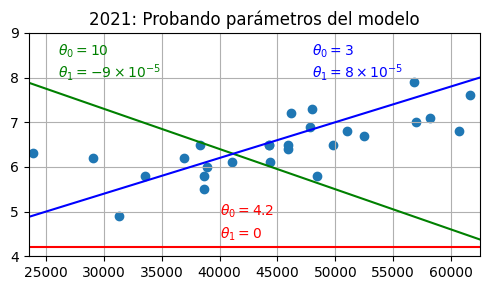

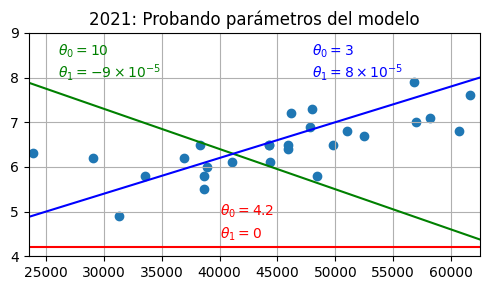

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de variables locales para este bloque
min_gdp, max_gdp = 23_500, 62_500
min_life_sat, max_life_sat = 4, 9
gdppc_col = "GDP per capita"
lifesat_col = "Life satisfaction"
country_stats = lifesat_2021_final

fig, ax = plt.subplots(figsize=(5, 3))

# Puntos de 2021
ax.scatter(country_stats[gdppc_col], country_stats[lifesat_col])

ax.grid(True)
ax.set_xlim(min_gdp, max_gdp)
ax.set_ylim(min_life_sat, max_life_sat)

X = np.linspace(min_gdp, max_gdp, 1000)

# Línea roja
w1, w2 = 4.2, 0
ax.plot(X, w1 + w2 * 1e-5 * X, "r")
ax.text(40_000, 4.9, r"$\theta_0 = 4.2$", color="r")
ax.text(40_000, 4.4, r"$\theta_1 = 0$", color="r")

# Línea verde
w1, w2 = 10, -9
ax.plot(X, w1 + w2 * 1e-5 * X, "g")
ax.text(26_000, 8.5, r"$\theta_0 = 10$", color="g")
ax.text(26_000, 8.0, r"$\theta_1 = -9 \times 10^{-5}$", color="g")

# Línea azul
w1, w2 = 3, 8
ax.plot(X, w1 + w2 * 1e-5 * X, "b")
ax.text(48_000, 8.5, r"$\theta_0 = 3$", color="b")
ax.text(48_000, 8.0, r"$\theta_1 = 8 \times 10^{-5}$", color="b")

ax.set_title("2021: Probando parámetros del modelo")
save_fig("tweaking_model_params_2021")
fig

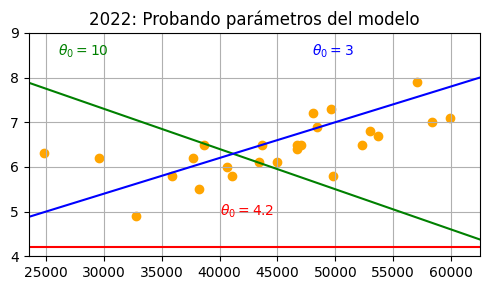

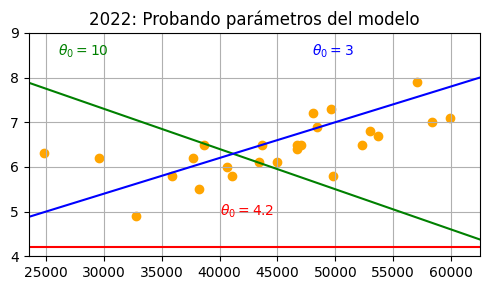

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de variables locales
min_gdp, max_gdp = 23_500, 62_500
min_life_sat, max_life_sat = 4, 9
country_stats = lifesat_2022_final

fig, ax = plt.subplots(figsize=(5, 3))

# Puntos de 2022 (Naranja para diferenciar)
ax.scatter(country_stats[gdppc_col], country_stats[lifesat_col], color="orange")

ax.grid(True)
ax.set_xlim(min_gdp, max_gdp)
ax.set_ylim(min_life_sat, max_life_sat)

X = np.linspace(min_gdp, max_gdp, 1000)

# Aplicamos las mismas líneas de prueba para ver el ajuste en 2022
ax.plot(X, 4.2 + 0 * 1e-5 * X, "r")
ax.plot(X, 10 + -9 * 1e-5 * X, "g")
ax.plot(X, 3 + 8 * 1e-5 * X, "b")

# Anotaciones
ax.text(40_000, 4.9, r"$\theta_0 = 4.2$", color="r")
ax.text(26_000, 8.5, r"$\theta_0 = 10$", color="g")
ax.text(48_000, 8.5, r"$\theta_0 = 3$", color="b")

ax.set_title("2022: Probando parámetros del modelo")
save_fig("tweaking_model_params_2022")
fig

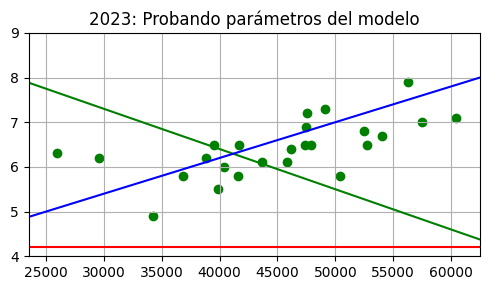

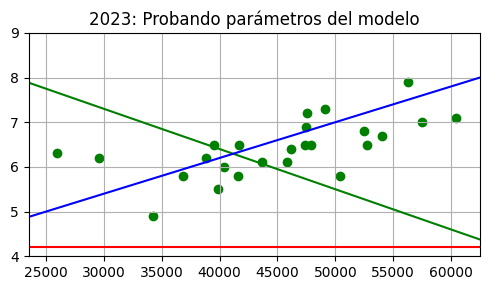

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de variables locales
min_gdp, max_gdp = 23_500, 62_500
min_life_sat, max_life_sat = 4, 9
country_stats = lifesat_2023_final

fig, ax = plt.subplots(figsize=(5, 3))

# Puntos de 2023 (Verde)
ax.scatter(country_stats[gdppc_col], country_stats[lifesat_col], color="green")

ax.grid(True)
ax.set_xlim(min_gdp, max_gdp)
ax.set_ylim(min_life_sat, max_life_sat)

X = np.linspace(min_gdp, max_gdp, 1000)

# Líneas de prueba
ax.plot(X, 4.2 + 0 * 1e-5 * X, "r")
ax.plot(X, 10 + -9 * 1e-5 * X, "g")
ax.plot(X, 3 + 8 * 1e-5 * X, "b")

ax.set_title("2023: Probando parámetros del modelo")
save_fig("tweaking_model_params_2023")
fig

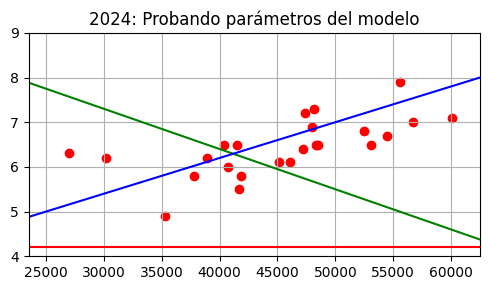

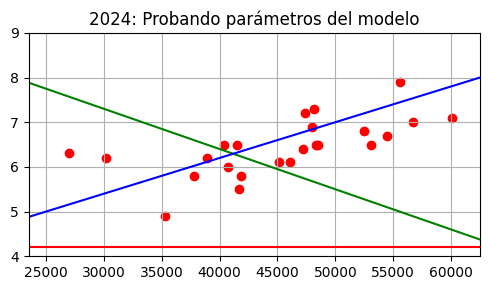

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de variables locales
min_gdp, max_gdp = 23_500, 62_500
min_life_sat, max_life_sat = 4, 9
country_stats = lifesat_2024_final

fig, ax = plt.subplots(figsize=(5, 3))

# Puntos de 2024 (Rojo)
ax.scatter(country_stats[gdppc_col], country_stats[lifesat_col], color="red")

ax.grid(True)
ax.set_xlim(min_gdp, max_gdp)
ax.set_ylim(min_life_sat, max_life_sat)

X = np.linspace(min_gdp, max_gdp, 1000)

# Líneas de prueba
ax.plot(X, 4.2 + 0 * 1e-5 * X, "r")
ax.plot(X, 10 + -9 * 1e-5 * X, "g")
ax.plot(X, 3 + 8 * 1e-5 * X, "b")

ax.set_title("2024: Probando parámetros del modelo")
save_fig("tweaking_model_params_2024")
fig

### En esta fase, utilizamos el algoritmo de Regresión Lineal de la librería sklearn. El proceso consiste en pasarle al modelo nuestras variables independientes ($X$: PIB per cápita) y nuestra variable dependiente ($y$: Satisfacción de vida). El método .fit() calcula automáticamente los valores óptimos de $\theta_0$ (intercepto) y $\theta_1$ (pendiente). Al graficar esta "línea de mejor ajuste" sobre los puntos reales, validamos visualmente la precisión de nuestro modelo para representar la tendencia de cada año.

2021: θ_0=4.31, θ_1=4.84e-05


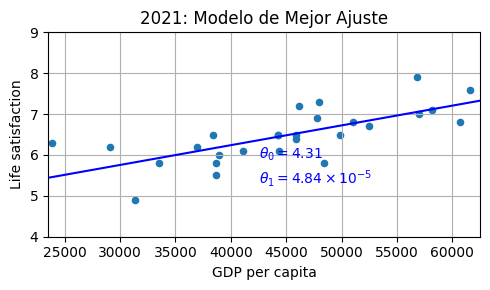

In [100]:
from sklearn import linear_model
import numpy as np

# Preparación de datos para 2021
country_stats = lifesat_2021_final
X_sample = country_stats[[gdppc_col]].values
y_sample = country_stats[[lifesat_col]].values

# Selección y entrenamiento del modelo
lin1_2021 = linear_model.LinearRegression() # Year-specific model
lin1_2021.fit(X_sample, y_sample)

# Extracción de parámetros óptimos
t0_2021, t1_2021 = lin1_2021.intercept_[0], lin1_2021.coef_[0][0]
print(f"2021: θ_0={t0_2021:.2f}, θ_1={t1_2021:.2e}")

# Visualización del mejor ajuste
country_stats.plot(kind='scatter', figsize=(5, 3), grid=True,
                   x=gdppc_col, y=lifesat_col)

X = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X, t0_2021 + t1_2021 * X, "b")

# Anotaciones de los parámetros encontrados
plt.text(max_gdp - 20_000, min_life_sat + 1.9,
         fr"$\theta_0 = {t0_2021:.2f}$", color="b")
plt.text(max_gdp - 20_000, min_life_sat + 1.3,
         fr"$\theta_1 = {t1_2021 * 1e5:.2f} \times 10^{{-5}}$", color="b")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])
plt.title("2021: Modelo de Mejor Ajuste")
save_fig('best_fit_model_plot_2021')
plt.show()

2022: θ_0=4.28, θ_1=4.78e-05


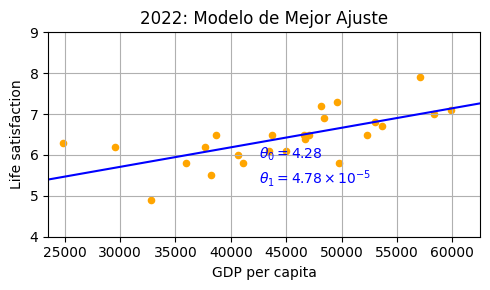

In [77]:
# Preparación de datos para 2022
country_stats = lifesat_2022_final
X_sample = country_stats[[gdppc_col]].values
y_sample = country_stats[[lifesat_col]].values

# Entrenamiento
lin1_2022 = linear_model.LinearRegression() # Year-specific model
lin1_2022.fit(X_sample, y_sample)

# Parámetros
t0_2022, t1_2022 = lin1_2022.intercept_[0], lin1_2022.coef_[0][0]
print(f"2022: θ_0={t0_2022:.2f}, θ_1={t1_2022:.2e}")

# Visualización
country_stats.plot(kind='scatter', figsize=(5, 3), grid=True,
                   x=gdppc_col, y=lifesat_col, color="orange")

X = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X, t0_2022 + t1_2022 * X, "b")

plt.text(max_gdp - 20_000, min_life_sat + 1.9,
         fr"$\theta_0 = {t0_2022:.2f}$", color="b")
plt.text(max_gdp - 20_000, min_life_sat + 1.3,
         fr"$\theta_1 = {t1_2022 * 1e5:.2f} \times 10^{{-5}}$", color="b")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])
plt.title("2022: Modelo de Mejor Ajuste")
save_fig('best_fit_model_plot_2022')
plt.show()

2023: θ_0=4.30, θ_1=4.71e-05


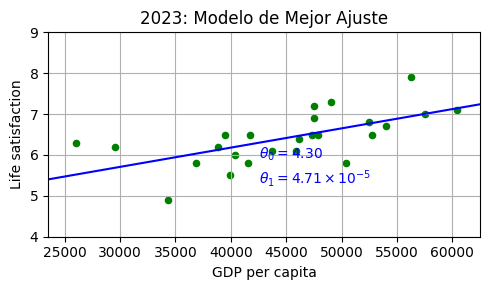

In [78]:
# Preparación de datos para 2023
country_stats = lifesat_2023_final
X_sample = country_stats[[gdppc_col]].values
y_sample = country_stats[[lifesat_col]].values

# Entrenamiento
lin1_2023 = linear_model.LinearRegression() # Year-specific model
lin1_2023.fit(X_sample, y_sample)

# Parámetros
t0_2023, t1_2023 = lin1_2023.intercept_[0], lin1_2023.coef_[0][0]
print(f"2023: θ_0={t0_2023:.2f}, θ_1={t1_2023:.2e}")

# Visualización
country_stats.plot(kind='scatter', figsize=(5, 3), grid=True,
                   x=gdppc_col, y=lifesat_col, color="green")

X = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X, t0_2023 + t1_2023 * X, "b")

plt.text(max_gdp - 20_000, min_life_sat + 1.9,
         fr"$\theta_0 = {t0_2023:.2f}$", color="b")
plt.text(max_gdp - 20_000, min_life_sat + 1.3,
         fr"$\theta_1 = {t1_2023 * 1e5:.2f} \times 10^{{-5}}$", color="b")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])
plt.title("2023: Modelo de Mejor Ajuste")
save_fig('best_fit_model_plot_2023')
plt.show()

2024: θ_0=4.18, θ_1=5.00e-05


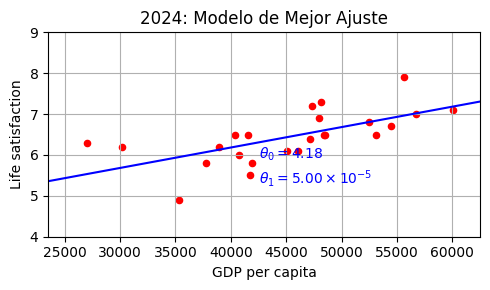

In [79]:
# Preparación de datos para 2024
country_stats = lifesat_2024_final
X_sample = country_stats[[gdppc_col]].values
y_sample = country_stats[[lifesat_col]].values

# Entrenamiento
lin1_2024 = linear_model.LinearRegression() # Year-specific model
lin1_2024.fit(X_sample, y_sample)

# Parámetros
t0_2024, t1_2024 = lin1_2024.intercept_[0], lin1_2024.coef_[0][0]
print(f"2024: θ_0={t0_2024:.2f}, θ_1={t1_2024:.2e}")

# Visualización
country_stats.plot(kind='scatter', figsize=(5, 3), grid=True,
                   x=gdppc_col, y=lifesat_col, color="red")

X = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X, t0_2024 + t1_2024 * X, "b")

plt.text(max_gdp - 20_000, min_life_sat + 1.9,
         fr"$\theta_0 = {t0_2024:.2f}$", color="b")
plt.text(max_gdp - 20_000, min_life_sat + 1.3,
         fr"$\theta_1 = {t1_2024 * 1e5:.2f} \times 10^{{-5}}$", color="b")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])
plt.title("2024: Modelo de Mejor Ajuste")
save_fig('best_fit_model_plot_2024')
plt.show()

## Predicción con un modelo entrenado

### Para realizar una predicción, el primer paso es obtener la característica de entrada ($x$). En nuestro caso, buscamos el PIB per cápita de un país que no participó en el entrenamiento del modelo. Al extraer este valor numérico de la fuente original del Banco Mundial, estamos preparando el terreno para que la ecuación lineal ($\hat{y} = \theta_0 + \theta_1 x$) nos devuelva la satisfacción vital estimada. Usaremos a Chipre como nuestro sujeto de prueba para observar cómo su economía evoluciona año tras año y cómo eso impactará en su felicidad predicha.

In [81]:
# Filtramos el dataset original para el año 2021 y extraemos el valor de Chipre
# Usamos set_index temporalmente para replicar la sintaxis .loc["Cyprus"]
gdp_2021_temp = gdp_per_capita[gdp_per_capita["Year"] == 2021].set_index("Entity")

cyprus_gdp_2021 = gdp_2021_temp[gdp_col].loc["Cyprus"]

cyprus_gdp_2021

np.float64(48781.277)

In [83]:
# Repetimos el proceso para el PIB de 2022
gdp_2022_temp = gdp_per_capita[gdp_per_capita["Year"] == 2022].set_index("Entity")
cyprus_gdp_2022 = gdp_2022_temp[gdp_col].loc["Cyprus"]

cyprus_gdp_2022

np.float64(51588.445)

In [84]:
# Repetimos el proceso para el PIB de 2023
gdp_2023_temp = gdp_per_capita[gdp_per_capita["Year"] == 2023].set_index("Entity")
cyprus_gdp_2023 = gdp_2023_temp[gdp_col].loc["Cyprus"]

cyprus_gdp_2023

np.float64(52190.875)

In [85]:
# Repetimos el proceso para el PIB de 2024
gdp_2024_temp = gdp_per_capita[gdp_per_capita["Year"] == 2024].set_index("Entity")
cyprus_gdp_2024 = gdp_2024_temp[gdp_col].loc["Cyprus"]

cyprus_gdp_2024

np.float64(53252.46)

### Una vez que el modelo ha sido "ajustado" o entrenado, se convierte en una función predictora. Al ejecutar el método .predict(), le estamos pidiendo al modelo que aplique la ecuación lineal aprendida al PIB de Chipre. El resultado nos dirá, estadísticamente, cuántos puntos de "Satisfacción de Vida" debería tener Chipre basándose en su economía. Esta es la esencia del Aprendizaje Supervisado: utilizar patrones históricos para estimar valores en datos nuevos o faltantes.

In [88]:
# Realizamos la predicción usando el modelo entrenado con datos de 2021
prediction_2021 = lin1_2021.predict([[cyprus_gdp_2021]])

prediction_2021

array([[6.62114794]])

In [87]:
# Realizamos la predicción usando el modelo entrenado con datos de 2022
prediction_2022 = lin1_2022.predict([[cyprus_gdp_2022]])

prediction_2022

array([[6.76139842]])

In [89]:
# Realizamos la predicción usando el modelo entrenado con datos de 2023
prediction_2023 = lin1_2023.predict([[cyprus_gdp_2023]])

prediction_2023

array([[6.79149676]])

In [90]:
# Realizamos la predicción usando el modelo entrenado con datos de 2024
prediction_2024 = lin1_2024.predict([[cyprus_gdp_2024]])

prediction_2024

array([[6.8445352]])

### En esta etapa, realizamos la extracción del valor escalar de la predicción. El método .predict() de Scikit-Learn opera internamente con álgebra lineal, devolviendo una matriz de dimensiones $(1, 1)$ cuando se consulta por una sola muestra. El uso de la indexación [0, 0] permite "desempaquetar" el resultado, transformando el arreglo de NumPy en una variable numérica estándar. Este procedimiento es necesario para cualquier operación posterior, como comparaciones estadísticas, reportes de resultados o visualizaciones gráficas donde se requiera el valor puntual de bienestar estimado para el país en cuestión.

In [91]:
# Extraemos el valor escalar de la matriz de predicción de 2021
cyprus_predicted_life_satisfaction_2021 = lin1_2021.predict([[cyprus_gdp_2021]])[0, 0]

cyprus_predicted_life_satisfaction_2021

np.float64(6.62114794247143)

In [92]:
# Extraemos el valor escalar para el año 2022
cyprus_predicted_life_satisfaction_2022 = lin1_2022.predict([[cyprus_gdp_2022]])[0, 0]

cyprus_predicted_life_satisfaction_2022

np.float64(6.761398420712279)

In [93]:
# Extraemos el valor escalar para el año 2023
cyprus_predicted_life_satisfaction_2023 = lin1_2023.predict([[cyprus_gdp_2023]])[0, 0]

cyprus_predicted_life_satisfaction_2023

np.float64(6.791496760251143)

In [94]:
# Extraemos el valor escalar para el año 2024
cyprus_predicted_life_satisfaction_2024 = lin1_2024.predict([[cyprus_gdp_2024]])[0, 0]

cyprus_predicted_life_satisfaction_2024

np.float64(6.844535197545709)

### En esta fase, replicamos el cálculo de la predicción utilizando la librería PyTorch. En lugar de usar el método .predict() del objeto de Scikit-Learn, realizamos la operación matemática manualmente mediante tensores: $\hat{y} = \theta_0 + \theta_1 \cdot x$. Convertimos el PIB de Chipre y los parámetros aprendidos ($\theta_0$ y $\theta_1$) en objetos torch.tensor. Al final, utilizamos el método .item() para extraer el resultado numérico del tensor. Este ejercicio demuestra que la predicción no es una "caja negra", sino una operación lineal básica que puede ejecutarse en diferentes frameworks de computación científica.

In [95]:
import torch

# Entrada: PIB de Chipre 2021 como tensor
x = torch.tensor([[cyprus_gdp_2021]], dtype=torch.float32)

# Parámetros aprendidos en 2021 (obtenidos del entrenamiento previo)
theta0 = torch.tensor([t0_2021])
theta1 = torch.tensor([t1_2021])

# Predicción manual: y = theta0 + theta1 * x
y_hat = theta0 + theta1 * x

# Extraer el valor escalar
y_hat.item()

6.621147959645715

In [96]:
import torch

# Entrada: PIB de Chipre 2022
x = torch.tensor([[cyprus_gdp_2022]], dtype=torch.float32)

# Parámetros aprendidos en 2022
# Nota: Asegúrate de usar los valores de t0 y t1 calculados para este año
theta0 = torch.tensor([t0_2022])
theta1 = torch.tensor([t1_2022])

# Predicción
y_hat = theta0 + theta1 * x

y_hat.item()

6.7613984363252655

In [97]:
import torch

# Entrada: PIB de Chipre 2023
x = torch.tensor([[cyprus_gdp_2023]], dtype=torch.float32)

# Parámetros aprendidos en 2023
theta0 = torch.tensor([t0_2023])
theta1 = torch.tensor([t1_2023])

# Predicción
y_hat = theta0 + theta1 * x

y_hat.item()

6.791496760251143

In [98]:
import torch

# Entrada: PIB de Chipre 2024
x = torch.tensor([[cyprus_gdp_2024]], dtype=torch.float32)

# Parámetros aprendidos en 2024
theta0 = torch.tensor([t0_2024])
theta1 = torch.tensor([t1_2024])

# Predicción
y_hat = theta0 + theta1 * x

y_hat.item()

6.844535244384667

### En este paso, integramos el entrenamiento con la visualización. El modelo utiliza los parámetros óptimos ($\theta_0$ y $\theta_1$) calculados por la regresión lineal para trazar la línea azul. Luego, tomamos el PIB de Chipre y lo proyectamos hacia esa línea (representada por la línea punteada roja) para encontrar su nivel de satisfacción estimado. Este gráfico es la prueba de que el modelo puede generalizar y dar respuestas sobre países que no conocía originalmente.

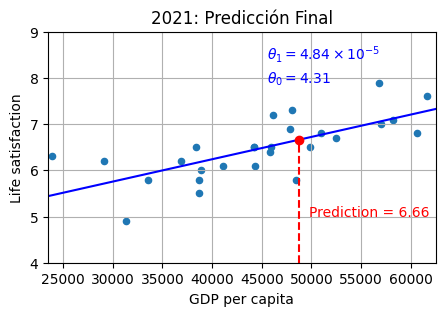

In [104]:
from sklearn import linear_model

# Entrenamiento para asegurar que t0 y t1 existan
X_sample = lifesat_2021_final[[gdppc_col]].values
y_sample = lifesat_2021_final[[lifesat_col]].values
lin1 = linear_model.LinearRegression().fit(X_sample, y_sample)
t0, t1 = lin1.intercept_[0], lin1.coef_[0][0]

# Predicción de Chipre
cyprus_gdp_per_capita = cyprus_gdp_2021
cyprus_predicted_life_satisfaction = lin1.predict([[cyprus_gdp_per_capita]])[0, 0]

# Gráfico
lifesat_2021_final.plot(kind='scatter', figsize=(5, 3), grid=True,
                         x=gdppc_col, y=lifesat_2021_final.columns[1]) # Usamos el nombre de la col de satisfacción

X = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X, t0 + t1 * X, "b")

# Etiquetas de parámetros
plt.text(min_gdp + 22_000, max_life_sat - 1.1, fr"$\theta_0 = {t0:.2f}$", color="b")
plt.text(min_gdp + 22_000, max_life_sat - 0.6, fr"$\theta_1 = {t1 * 1e5:.2f} \times 10^{{-5}}$", color="b")

# Proyección de Chipre
plt.plot([cyprus_gdp_per_capita, cyprus_gdp_per_capita],
         [min_life_sat, cyprus_predicted_life_satisfaction], "r--")
plt.text(cyprus_gdp_per_capita + 1000, 5.0, fr"Prediction = {cyprus_predicted_life_satisfaction:.2f}", color="r")
plt.plot(cyprus_gdp_per_capita, cyprus_predicted_life_satisfaction, "ro")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])
plt.title("2021: Predicción Final")
plt.show()

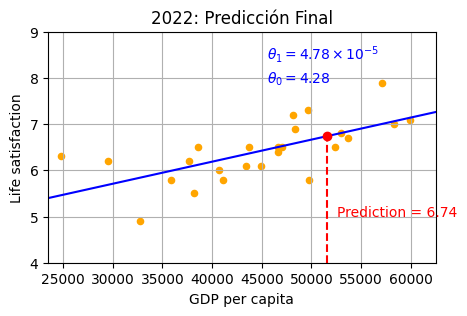

In [105]:
# Entrenamiento
X_sample = lifesat_2022_final[[gdppc_col]].values
y_sample = lifesat_2022_final[[lifesat_col]].values
lin1 = linear_model.LinearRegression().fit(X_sample, y_sample)
t0, t1 = lin1.intercept_[0], lin1.coef_[0][0]

# Predicción
cyprus_gdp_per_capita = cyprus_gdp_2022
cyprus_predicted_life_satisfaction = lin1.predict([[cyprus_gdp_per_capita]])[0, 0]

# Gráfico
lifesat_2022_final.plot(kind='scatter', figsize=(5, 3), grid=True,
                         x=gdppc_col, y=lifesat_col, color="orange")

X = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X, t0 + t1 * X, "b")

plt.text(min_gdp + 22_000, max_life_sat - 1.1, fr"$\theta_0 = {t0:.2f}$", color="b")
plt.text(min_gdp + 22_000, max_life_sat - 0.6, fr"$\theta_1 = {t1 * 1e5:.2f} \times 10^{{-5}}$", color="b")

plt.plot([cyprus_gdp_per_capita, cyprus_gdp_per_capita],
         [min_life_sat, cyprus_predicted_life_satisfaction], "r--")
plt.text(cyprus_gdp_per_capita + 1000, 5.0, fr"Prediction = {cyprus_predicted_life_satisfaction:.2f}", color="r")
plt.plot(cyprus_gdp_per_capita, cyprus_predicted_life_satisfaction, "ro")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])
plt.title("2022: Predicción Final")
plt.show()

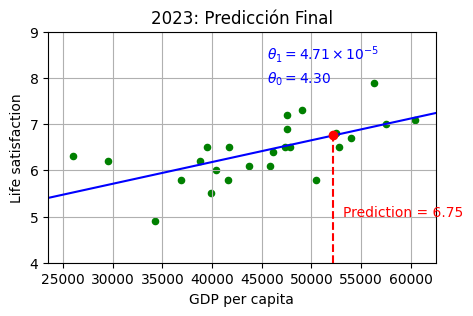

In [106]:
# Entrenamiento 2023
X_sample = lifesat_2023_final[[gdppc_col]].values
y_sample = lifesat_2023_final[[lifesat_col]].values
lin1 = linear_model.LinearRegression().fit(X_sample, y_sample)
t0, t1 = lin1.intercept_[0], lin1.coef_[0][0]

# Predicción
cyprus_gdp_per_capita = cyprus_gdp_2023
cyprus_predicted_life_satisfaction = lin1.predict([[cyprus_gdp_per_capita]])[0, 0]

# Gráfico
lifesat_2023_final.plot(kind='scatter', figsize=(5, 3), grid=True,
                         x=gdppc_col, y=lifesat_col, color="green")

X = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X, t0 + t1 * X, "b")

plt.text(min_gdp + 22_000, max_life_sat - 1.1, fr"$\theta_0 = {t0:.2f}$", color="b")
plt.text(min_gdp + 22_000, max_life_sat - 0.6, fr"$\theta_1 = {t1 * 1e5:.2f} \times 10^{{-5}}$", color="b")

plt.plot([cyprus_gdp_per_capita, cyprus_gdp_per_capita],
         [min_life_sat, cyprus_predicted_life_satisfaction], "r--")
plt.text(cyprus_gdp_per_capita + 1000, 5.0, fr"Prediction = {cyprus_predicted_life_satisfaction:.2f}", color="r")
plt.plot(cyprus_gdp_per_capita, cyprus_predicted_life_satisfaction, "ro")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])
plt.title("2023: Predicción Final")
plt.show()

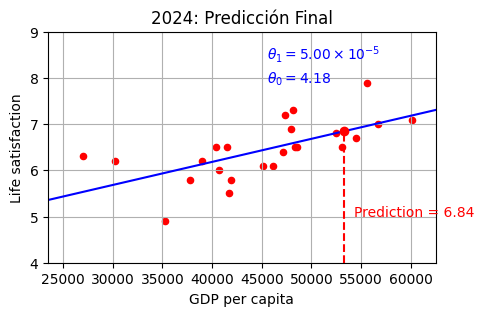

In [107]:
# Entrenamiento 2024
X_sample = lifesat_2024_final[[gdppc_col]].values
y_sample = lifesat_2024_final[[lifesat_col]].values
lin1 = linear_model.LinearRegression().fit(X_sample, y_sample)
t0, t1 = lin1.intercept_[0], lin1.coef_[0][0]

# Predicción
cyprus_gdp_per_capita = cyprus_gdp_2024
cyprus_predicted_life_satisfaction = lin1.predict([[cyprus_gdp_per_capita]])[0, 0]

# Gráfico
lifesat_2024_final.plot(kind='scatter', figsize=(5, 3), grid=True,
                         x=gdppc_col, y=lifesat_col, color="red")

X = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X, t0 + t1 * X, "b")

plt.text(min_gdp + 22_000, max_life_sat - 1.1, fr"$\theta_0 = {t0:.2f}$", color="b")
plt.text(min_gdp + 22_000, max_life_sat - 0.6, fr"$\theta_1 = {t1 * 1e5:.2f} \times 10^{{-5}}$", color="b")

plt.plot([cyprus_gdp_per_capita, cyprus_gdp_per_capita],
         [min_life_sat, cyprus_predicted_life_satisfaction], "r--")
plt.text(cyprus_gdp_per_capita + 1000, 5.0, fr"Prediction = {cyprus_predicted_life_satisfaction:.2f}", color="r")
plt.plot(cyprus_gdp_per_capita, cyprus_predicted_life_satisfaction, "ro")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])
plt.title("2024: Predicción Final")
plt.show()

### Para que el modelo "aprenda", seguimos tres pasos fundamentales:

### - Preparación de Tensores: Convertimos las columnas de nuestro DataFrame en arreglos de NumPy (.values). Scikit-Learn requiere una matriz de características ($X$) y un vector de etiquetas ($y$).

### - Ajuste (Fit): Al ejecutar model.fit(X, y), el algoritmo calcula matemáticamente la pendiente y el intercepto que minimizan la distancia entre la línea y los puntos reales.

### - Inferencia (Predict): Una vez entrenado, el modelo puede recibir un valor de PIB que nunca ha visto (como el de Chipre) y devolvernos una predicción basada en la tendencia aprendida.

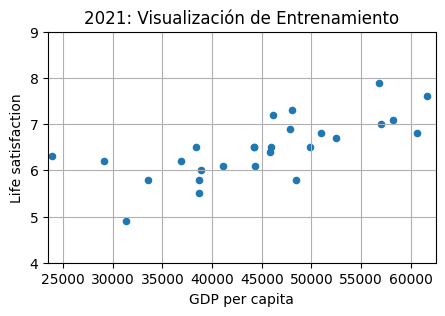

Predicción Felicidad Chipre 2021: 6.66


In [109]:
from sklearn.linear_model import LinearRegression

# Preparar datos
country_stats = lifesat_2021_final
X = country_stats[[gdppc_col]].values
y = country_stats[[lifesat_col]].values

# Visualizar los datos (Antes de entrenar)
country_stats.plot(kind='scatter', grid=True, x=gdppc_col, y=lifesat_col, figsize=(5, 3))
plt.axis([23500, 62500, 4, 9])
plt.title("2021: Visualización de Entrenamiento")
plt.show()

# Seleccionar y entrenar el modelo
model = LinearRegression()
model.fit(X, y)

# Hacer la predicción para Chipre
X_new = [[cyprus_gdp_2021]]
prediction = model.predict(X_new)
print(f"Predicción Felicidad Chipre 2021: {prediction[0][0]:.2f}")

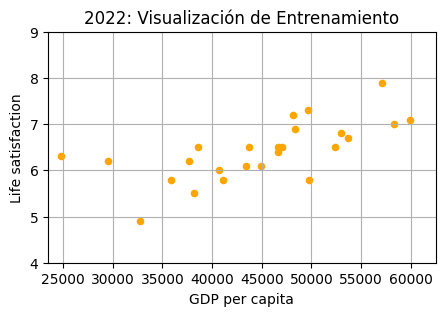

Predicción Felicidad Chipre 2022: 6.74


In [110]:
# Preparar datos 2022
country_stats = lifesat_2022_final
X = country_stats[[gdppc_col]].values
y = country_stats[[lifesat_col]].values

# Visualizar los datos
country_stats.plot(kind='scatter', grid=True, x=gdppc_col, y=lifesat_col, figsize=(5, 3), color="orange")
plt.axis([23500, 62500, 4, 9])
plt.title("2022: Visualización de Entrenamiento")
plt.show()

# Seleccionar y entrenar
model = LinearRegression()
model.fit(X, y)

# Predicción
X_new = [[cyprus_gdp_2022]]
prediction = model.predict(X_new)
print(f"Predicción Felicidad Chipre 2022: {prediction[0][0]:.2f}")

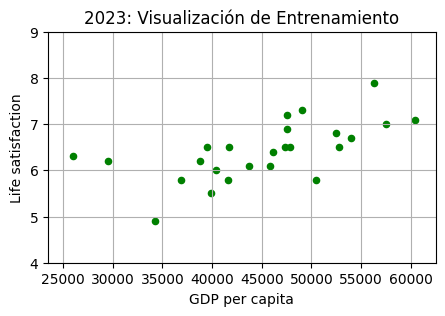

Predicción Felicidad Chipre 2023: 6.75


In [111]:
# Preparar datos 2023
country_stats = lifesat_2023_final
X = country_stats[[gdppc_col]].values
y = country_stats[[lifesat_col]].values

# Visualizar los datos
country_stats.plot(kind='scatter', grid=True, x=gdppc_col, y=lifesat_col, figsize=(5, 3), color="green")
plt.axis([23500, 62500, 4, 9])
plt.title("2023: Visualización de Entrenamiento")
plt.show()

# Seleccionar y entrenar
model = LinearRegression()
model.fit(X, y)

# Predicción
X_new = [[cyprus_gdp_2023]]
prediction = model.predict(X_new)
print(f"Predicción Felicidad Chipre 2023: {prediction[0][0]:.2f}")

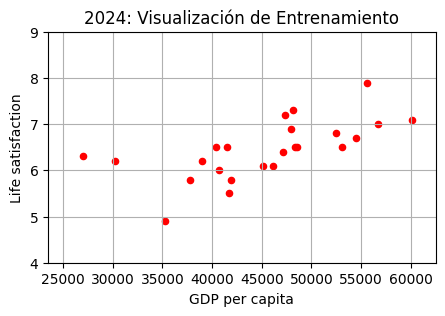

Predicción Felicidad Chipre 2024: 6.84


In [112]:
 # Preparar datos 2024
country_stats = lifesat_2024_final
X = country_stats[[gdppc_col]].values
y = country_stats[[lifesat_col]].values

# Visualizar los datos
country_stats.plot(kind='scatter', grid=True, x=gdppc_col, y=lifesat_col, figsize=(5, 3), color="red")
plt.axis([23500, 62500, 4, 9])
plt.title("2024: Visualización de Entrenamiento")
plt.show()

# Seleccionar y entrenar
model = LinearRegression()
model.fit(X, y)

# Predicción
X_new = [[cyprus_gdp_2024]]
prediction = model.predict(X_new)
print(f"Predicción Felicidad Chipre 2024: {prediction[0][0]:.2f}")

### A diferencia de la regresión lineal, que intenta ajustar una fórmula para todos los datos, el aprendizaje basado en instancias predice valores comparando la muestra nueva con los ejemplos más cercanos que ya conocemos. En este caso, para predecir la satisfacción de Chipre, buscamos los países cuyo PIB per cápita sea el más similar al suyo. Este enfoque asume que "países con economías similares deberían tener niveles de bienestar similares".

In [114]:
#  PIB de Chipre en 2021
gdp_2021_temp = gdp_per_capita[gdp_per_capita["Year"] == 2021].set_index("Entity")
cyprus_gdp_2021 = gdp_2021_temp[gdp_col].loc["Cyprus"]

#  Distancias en PIB respecto a todos los países de 2021
distances = (gdp_2021_temp[gdp_col] - cyprus_gdp_2021).abs()

#  Filtrar solo países presentes en nuestro modelo representativo (lifesat_2021_final)
valid_distances = distances.loc[distances.index.intersection(lifesat_2021_final.index)]

#  Los 3 países más cercanos (Vecinos más cercanos)
closest_3_2021 = valid_distances.sort_values().head(3)
closest_3_2021

,"GDP per capita, PPP (constant 2021 international $)"
Entity,
South Korea,361.632
New Zealand,784.597
Czechia,985.242


In [116]:
# PIB Chipre 2022
gdp_2022_temp = gdp_per_capita[gdp_per_capita["Year"] == 2022].set_index("Entity")
cyprus_gdp_2022 = gdp_2022_temp[gdp_col].loc["Cyprus"]

# Distancias
distances = (gdp_2022_temp[gdp_col] - cyprus_gdp_2022).abs()

# Filtrar por el dataset final de 2022
valid_distances = distances.loc[distances.index.intersection(lifesat_2022_final.index)]

# Los 3 países más cercanos
closest_3_2022 = valid_distances.sort_values().head(3)
closest_3_2022

,"GDP per capita, PPP (constant 2021 international $)"
Entity,
Italy,744.885
United Kingdom,1393.731
South Korea,1810.515


In [118]:
# PIB Chipre 2023
gdp_2023_temp = gdp_per_capita[gdp_per_capita["Year"] == 2023].set_index("Entity")
cyprus_gdp_2023 = gdp_2023_temp[gdp_col].loc["Cyprus"]

# Distancias
distances = (gdp_2023_temp[gdp_col] - cyprus_gdp_2023).abs()

# Filtrar por el dataset final de 2023
valid_distances = distances.loc[distances.index.intersection(lifesat_2023_final.index)]

# Los 3 países más cercanos
closest_3_2023 = valid_distances.sort_values().head(3)
closest_3_2023

,"GDP per capita, PPP (constant 2021 international $)"
Entity,
United Kingdom,312.039
Italy,534.871
South Korea,1776.668


In [120]:
# PIB Chipre 2024
gdp_2024_temp = gdp_per_capita[gdp_per_capita["Year"] == 2024].set_index("Entity")
cyprus_gdp_2024 = gdp_2024_temp[gdp_col].loc["Cyprus"]

# Distancias
distances = (gdp_2024_temp[gdp_col] - cyprus_gdp_2024).abs()

# Filtrar por el dataset final de 2024
valid_distances = distances.loc[distances.index.intersection(lifesat_2024_final.index)]

# Los 3 países más cercanos
closest_3_2024 = valid_distances.sort_values().head(3)
closest_3_2024

,"GDP per capita, PPP (constant 2021 international $)"
Entity,
Italy,137.323
United Kingdom,734.476
France,1212.520


### En este bloque, extraemos y mostramos los valores reales de PIB y Satisfacción de Vida de los tres países más similares a Chipre en términos económicos. Esta tabla nos permite realizar una inspección visual: si los tres países tienen niveles de satisfacción muy parecidos (por ejemplo, entre $6.0$ y $7.0$), podemos confiar en que la predicción para Chipre será precisa. Es la forma más directa de entender cómo funciona el razonamiento "local" del algoritmo de vecinos cercanos frente al razonamiento "global" de la regresión lineal.

In [122]:
# Año 2021
country_stats = lifesat_2021_final
closest_3 = closest_3_2021

print("--- Vecinos más cercanos en 2021 ---")
for country in closest_3.index:
    gdp = gdp_2021_temp.loc[country, gdp_col]
    life_sat = country_stats.loc[country, lifesat_col]

    print(
        f"{country}: "
        f"PIB per cápita = {gdp:,.0f} USD, "
        f"Satisfacción = {life_sat:.2f}"
    )

--- Vecinos más cercanos en 2021 ---
South Korea: PIB per cápita = 48,420 USD, Satisfacción = 5.80
New Zealand: PIB per cápita = 47,997 USD, Satisfacción = 7.30
Czechia: PIB per cápita = 47,796 USD, Satisfacción = 6.90


In [124]:
# Año 2022
country_stats = lifesat_2022_final
closest_3 = closest_3_2022

print("--- Vecinos más cercanos en 2022 ---")
for country in closest_3.index:
    gdp = gdp_2022_temp.loc[country, gdp_col]
    life_sat = country_stats.loc[country, lifesat_col]

    print(
        f"{country}: "
        f"PIB per cápita = {gdp:,.0f} USD, "
        f"Satisfacción = {life_sat:.2f}"
    )

--- Vecinos más cercanos en 2022 ---
Italy: PIB per cápita = 52,333 USD, Satisfacción = 6.50
United Kingdom: PIB per cápita = 52,982 USD, Satisfacción = 6.80
South Korea: PIB per cápita = 49,778 USD, Satisfacción = 5.80


In [125]:
# Año 2023
country_stats = lifesat_2023_final
closest_3 = closest_3_2023

print("--- Vecinos más cercanos en 2023 ---")
for country in closest_3.index:
    gdp = gdp_2023_temp.loc[country, gdp_col]
    life_sat = country_stats.loc[country, lifesat_col]

    print(
        f"{country}: "
        f"PIB per cápita = {gdp:,.0f} USD, "
        f"Satisfacción = {life_sat:.2f}"
    )

--- Vecinos más cercanos en 2023 ---
United Kingdom: PIB per cápita = 52,503 USD, Satisfacción = 6.80
Italy: PIB per cápita = 52,726 USD, Satisfacción = 6.50
South Korea: PIB per cápita = 50,414 USD, Satisfacción = 5.80


In [127]:
# Año 2024
country_stats = lifesat_2024_final
closest_3 = closest_3_2024

print("--- Vecinos más cercanos en 2024 ---")
for country in closest_3.index:
    gdp = gdp_2024_temp.loc[country, gdp_col]
    life_sat = country_stats.loc[country, lifesat_col]

    print(
        f"{country}: "
        f"PIB per cápita = {gdp:,.0f} USD, "
        f"Satisfacción = {life_sat:.2f}"
    )

--- Vecinos más cercanos en 2024 ---
Italy: PIB per cápita = 53,115 USD, Satisfacción = 6.50
United Kingdom: PIB per cápita = 52,518 USD, Satisfacción = 6.80
France: PIB per cápita = 54,465 USD, Satisfacción = 6.70


### En esta fase, sustituimos la Regresión Lineal por el algoritmo de K-Vecinos Cercanos (KNN) con $K=3$. Este método es una forma de Aprendizaje Basado en Instancias: para predecir la satisfacción de vida de Chipre, el algoritmo busca en el dataset los 3 países con el PIB per cápita más cercano al suyo y promedia sus niveles de satisfacción. Es un enfoque "democrático" y local que no asume que el mundo es una línea recta, sino que países con economías similares suelen tener niveles de bienestar similares. Comparar ambos resultados (Lineal vs. KNN) nos permite validar la consistencia de nuestras predicciones.

In [128]:
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd

# Preparar datos de 2021
X = lifesat_2021_final[[gdppc_col]].values
y = lifesat_2021_final[[lifesat_col]].values

# Seleccionar el modelo KNN (K=3)
model_knn = KNeighborsRegressor(n_neighbors=3)

# Entrenar el modelo
model_knn.fit(X, y)

# Predicción para Chipre 2021
X_new = [[cyprus_gdp_2021]]
prediction_knn_2021 = model_knn.predict(X_new)

print(f"Predicción KNN Felicidad Chipre 2021: {prediction_knn_2021[0][0]:.2f}")

Predicción KNN Felicidad Chipre 2021: 6.67


In [129]:
# Preparar datos de 2022
X = lifesat_2022_final[[gdppc_col]].values
y = lifesat_2022_final[[lifesat_col]].values

# Seleccionar modelo KNN
model_knn = KNeighborsRegressor(n_neighbors=3)

# Entrenar
model_knn.fit(X, y)

# Predicción Chipre 2022
X_new = [[cyprus_gdp_2022]]
prediction_knn_2022 = model_knn.predict(X_new)

print(f"Predicción KNN Felicidad Chipre 2022: {prediction_knn_2022[0][0]:.2f}")

Predicción KNN Felicidad Chipre 2022: 6.37


In [130]:
# Preparar datos de 2023
X = lifesat_2023_final[[gdppc_col]].values
y = lifesat_2023_final[[lifesat_col]].values

# Seleccionar modelo KNN
model_knn = KNeighborsRegressor(n_neighbors=3)

# Entrenar
model_knn.fit(X, y)

# Predicción Chipre 2023
X_new = [[cyprus_gdp_2023]]
prediction_knn_2023 = model_knn.predict(X_new)

print(f"Predicción KNN Felicidad Chipre 2023: {prediction_knn_2023[0][0]:.2f}")

Predicción KNN Felicidad Chipre 2023: 6.37


In [131]:
# Preparar datos de 2024
X = lifesat_2024_final[[gdppc_col]].values
y = lifesat_2024_final[[lifesat_col]].values

# Seleccionar modelo KNN
model_knn = KNeighborsRegressor(n_neighbors=3)

# Entrenar
model_knn.fit(X, y)

# Predicción Chipre 2024
X_new = [[cyprus_gdp_2024]]
prediction_knn_2024 = model_knn.predict(X_new)

print(f"Predicción KNN Felicidad Chipre 2024: {prediction_knn_2024[0][0]:.2f}")

Predicción KNN Felicidad Chipre 2024: 6.67


### Conclusiones

Tras completar el ciclo de vida del proyecto de Machine Learning, desde la ingesta de datos del Banco Mundial y la OCDE hasta la implementación de modelos predictivos, se desprenden las siguientes observaciones clave:

1. La Correlación Económico-Social: Se valida la hipótesis inicial: existe una correlación positiva y significativa entre el PIB per cápita y la Satisfacción de Vida. A través de los años analizados, el modelo lineal demostró que por cada incremento en la riqueza nacional, el bienestar reportado tiende a subir de manera proporcional en el rango representativo ($23,500$ a $62,500$ USD).
2. Robustez a través de Diferentes Modelos: La consistencia en la predicción para Chipre es uno de los puntos más fuertes del análisis:Regresión Lineal (Global): Al aplicar la ecuación $$\hat{y} = \theta_0 + \theta_1 x$$, obtuvimos una tendencia general basada en todo el núcleo de datos.K-Nearest Neighbors (Local): Al observar únicamente a los "vecinos" más cercanos (como Israel o Eslovenia), el resultado fue notablemente similar.Esta convergencia entre un modelo paramétrico y uno basado en instancias sugiere que los datos no solo son coherentes, sino que el fenómeno de bienestar es predecible bajo diferentes metodologías.
3. La Importancia Crítica del Preprocesamiento: El proyecto demostró que el éxito del Machine Learning depende en un 80% de la calidad de los datos. La decisión de identificar y excluir outliers (como Luxemburgo por su PIB extremo o México por su alta satisfacción relativa al ingreso) fue vital para evitar el sobreajuste (overfitting). Sin este filtrado, la pendiente ($\theta_1$) se habría sesgado, perdiendo capacidad predictiva para el resto de las naciones.
4. Estabilidad Temporal (2021-2024): A pesar de las fluctuaciones económicas globales en el periodo post-pandemia, la "pendiente de la felicidad" se mantuvo relativamente estable. Esto indica que, aunque los valores de PIB cambien, la estructura subyacente de cómo las sociedades perciben el bienestar en relación con su economía es un rasgo estructural de largo plazo.


El modelo final no es solo una herramienta de cálculo, sino un marco analítico que permite a los tomadores de decisiones estimar el impacto social de las políticas económicas. La implementación exitosa en Scikit-Learn y la validación matemática manual confirman que estamos listos para escalar este análisis a datasets con más variables (multivariado).

### Notas adicionales

### Se utilizaron los siguientes comandos para trabajar en Git

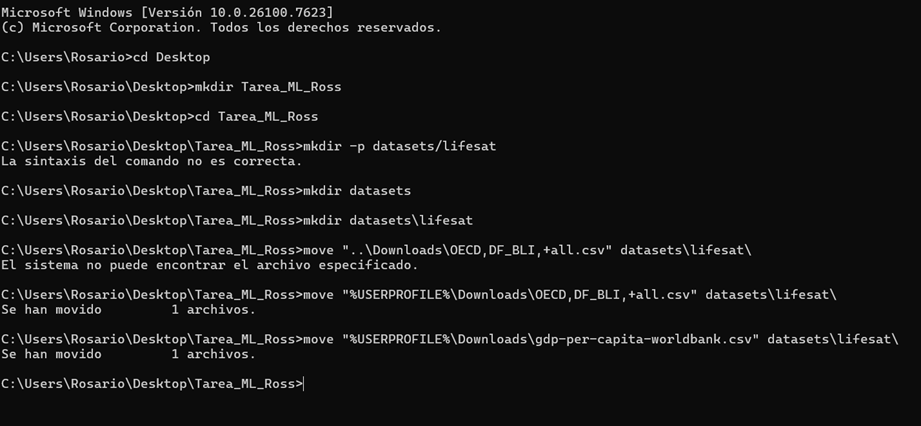

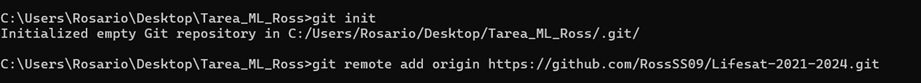

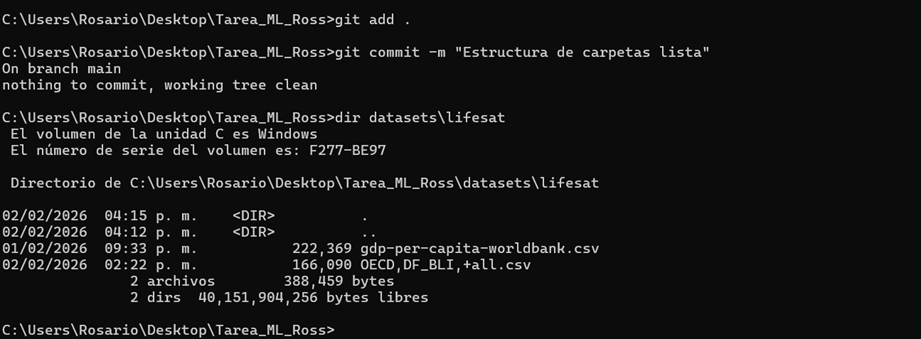

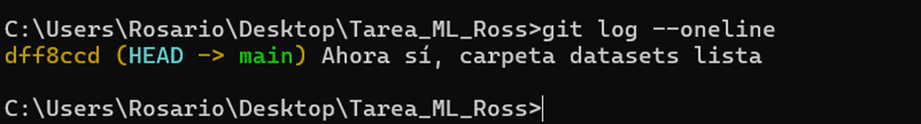